In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

print("Dataset loaded successfully!")


Dataset loaded successfully!


In [8]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of Rows: 250000
Number of Columns: 13

Column Names:
['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn']


In [9]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [10]:
df.tail()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
249995,33308,2023-08-10 13:39:06,Clothing,279,2,2187,PayPal,55,1.0,Michelle Flores,55,Male,1
249996,48835,2021-11-23 01:30:42,Home,27,1,3615,Credit Card,42,1.0,Jeremy Rush,42,Female,1
249997,21019,2020-07-02 14:04:48,Home,17,5,2466,Cash,41,0.0,Tina Craig,41,Male,0
249998,49234,2020-12-30 02:02:40,Books,398,2,3668,Crypto,34,0.0,Jennifer Cooper,34,Female,1
249999,16971,2021-03-13 16:28:35,Electronics,425,4,2370,Cash,36,1.0,Justin Lawson,36,Female,1


In [11]:
df.sample(10)

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
117175,21108,2023-06-24 08:07:44,Home,233,3,3590,PayPal,56,NaN,Rita Williams,56,Female,1
208433,33961,2022-10-24 05:10:19,Home,303,1,3610,Cash,48,1.0,Christopher Grant DVM,48,Female,0
158359,3624,2022-06-27 22:07:20,Home,312,4,2979,Credit Card,60,1.0,Timothy Hicks,60,Female,0
237185,12276,2022-08-11 01:36:12,Clothing,169,4,643,PayPal,43,NaN,Benjamin Sanchez,43,Female,0
86519,23893,2022-11-20 13:18:10,Home,231,5,4049,Cash,62,1.0,Christopher Munoz,62,Male,1
55569,32142,2021-01-07 11:38:10,Clothing,219,5,1827,PayPal,67,NaN,Mr. Jonathan Sawyer,67,Male,0
14237,12563,2022-12-28 04:07:50,Electronics,73,5,4498,Cash,54,NaN,Danielle Alexander,54,Male,1
121874,26760,2020-12-21 09:10:57,Books,475,5,277,Credit Card,31,NaN,Toni Medina,31,Male,0
4172,20615,2022-02-02 16:08:04,Clothing,28,5,1467,Credit Card,54,0.0,David Clark,54,Female,0
164129,12467,2021-06-21 03:26:10,Electronics,26,5,4123,Credit Card,70,0.0,Judy Miller,70,Male,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [13]:
missing = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_percentage
})

missing_table

,Missing Values,Missing %
Customer ID,0,0.00
Purchase Date,0,0.00
Product Category,0,0.00
Product Price,0,0.00
Quantity,0,0.00
Total Purchase Amount,0,0.00
Payment Method,0,0.00
Customer Age,0,0.00
Returns,47596,19.04
Customer Name,0,0.00


In [14]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [15]:
unique_customers = df["Customer ID"].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 49673


In [16]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

print("Minimum Date:", df["Purchase Date"].min())
print("Maximum Date:", df["Purchase Date"].max())

Minimum Date: 2020-01-01 00:15:00
Maximum Date: 2023-09-15 12:24:08


In [18]:
df["Year"] = df["Purchase Date"].dt.year
df["Month"] = df["Purchase Date"].dt.month
df["Month_Name"] = df["Purchase Date"].dt.month_name()

In [21]:
category_counts = df["Product Category"].value_counts()

print(category_counts)

Product Category
Clothing       75052
Books          74912
Electronics    50185
Home           49851
Name: count, dtype: int64


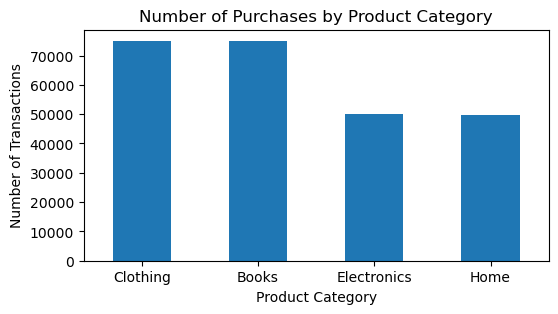

In [23]:
plt.figure(figsize=(6,3))

category_counts.plot(kind="bar")

plt.title("Number of Purchases by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

In [24]:
payment_counts = df["Payment Method"].value_counts()

payment_counts

Payment Method
Credit Card    100486
PayPal          74837
Cash            49894
Crypto          24783
Name: count, dtype: int64

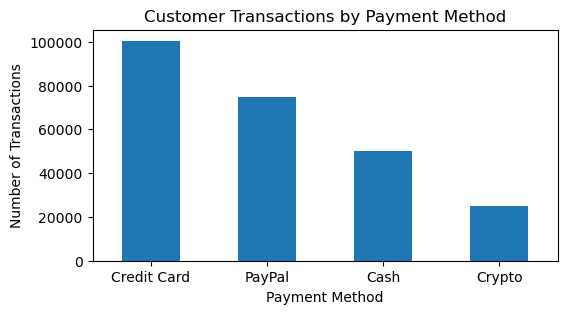

In [26]:
plt.figure(figsize=(6,3))

payment_counts.plot(kind="bar")

plt.title("Customer Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

In [27]:
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Female    125560
Male      124440
Name: count, dtype: int64

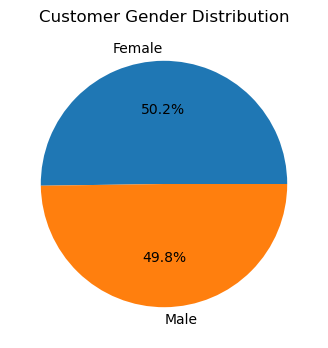

In [29]:
plt.figure(figsize=(7,4))

gender_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Customer Gender Distribution")
plt.ylabel("")

plt.show()

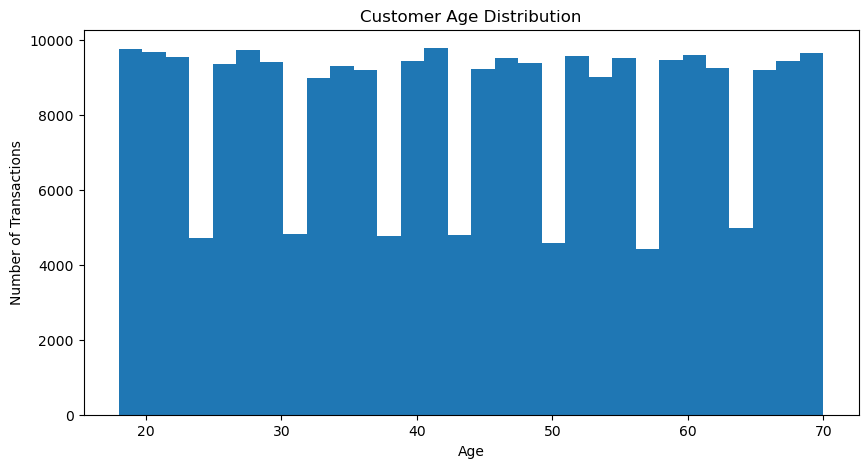

In [32]:
plt.figure(figsize=(10,5))

plt.hist(df["Customer Age"], bins=30)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Transactions")

plt.show()

In [33]:
print("Minimum Age:", df["Customer Age"].min())
print("Maximum Age:", df["Customer Age"].max())
print("Average Age:", df["Customer Age"].mean())

Minimum Age: 18
Maximum Age: 70
Average Age: 43.940528


In [34]:
df["Total Purchase Amount"].describe()

count    250000.000000
mean       2725.370732
std        1442.933565
min         100.000000
25%        1477.000000
50%        2724.000000
75%        3974.000000
max        5350.000000
Name: Total Purchase Amount, dtype: float64

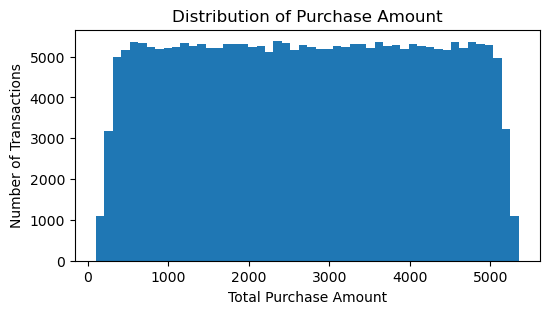

In [36]:
plt.figure(figsize=(6,3))

plt.hist(df["Total Purchase Amount"], bins=50)

plt.title("Distribution of Purchase Amount")
plt.xlabel("Total Purchase Amount")
plt.ylabel("Number of Transactions")

plt.show()

In [37]:
df["Quantity"].describe()

count    250000.000000
mean          2.998896
std           1.414694
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Quantity, dtype: float64

In [38]:
df["Quantity"].value_counts().sort_index()

Quantity
1    50108
2    50021
3    49872
4    50037
5    49962
Name: count, dtype: int64

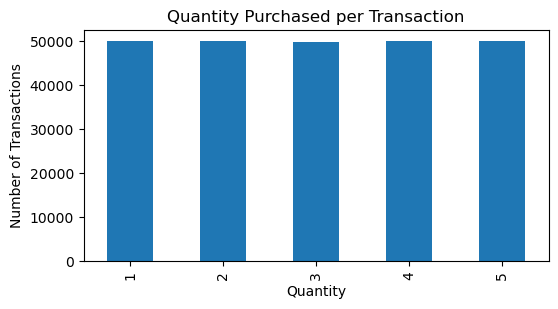

In [40]:
plt.figure(figsize=(6,3))

df["Quantity"].value_counts().sort_index().plot(kind="bar")

plt.title("Quantity Purchased per Transaction")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")

plt.show()

In [41]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
0    200126
1     49874
Name: count, dtype: int64


In [42]:
churn_rate = df["Churn"].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 19.95%


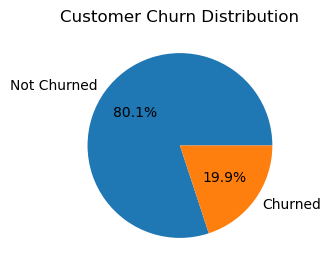

In [43]:
plt.figure(figsize=(6,3))

churn_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Not Churned", "Churned"]
)

plt.title("Customer Churn Distribution")
plt.ylabel("")

plt.show()

In [44]:
print(df["Returns"].value_counts(dropna=False))

Returns
0.0    101635
1.0    100769
NaN     47596
Name: count, dtype: int64


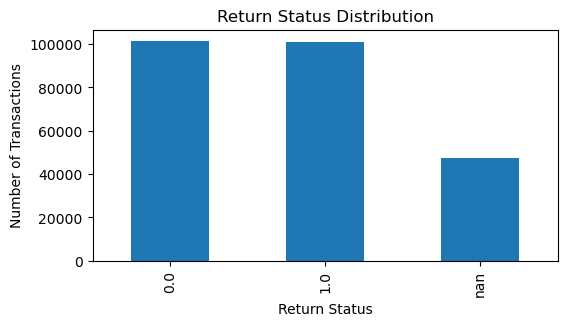

In [46]:
plt.figure(figsize=(6,3))

df["Returns"].value_counts(dropna=False).plot(kind="bar")

plt.title("Return Status Distribution")
plt.xlabel("Return Status")
plt.ylabel("Number of Transactions")

plt.show()

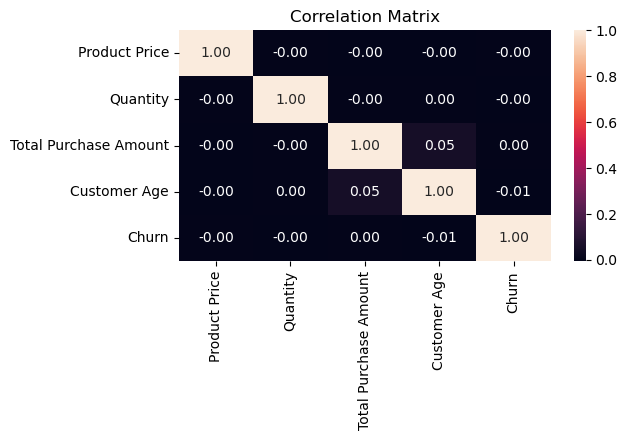

In [49]:
numeric_columns = [
    "Product Price",
    "Quantity",
    "Total Purchase Amount",
    "Customer Age",
    "Churn"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(6,3))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()